# Problem Set 1 — ¿Qué distingue a un género musical?

**S100 · Introducción a la Ciencia de Datos** · Maestría en Analítica de Datos, UTP
**Prof. Gabriel Soto, M.Sc.** · II Semestre 2026

**Modalidad:** individual · **Datos:** `spotify_songs.csv` (32,833 canciones)

---

## El caso

Una plataforma de streaming quiere entender **en qué se diferencian los géneros musicales**
según las características de audio de sus canciones. Te pasan la tabla completa y cinco
preguntas que van de lo general a lo específico.

Los cinco ejercicios están **encadenados**: cada uno usa resultados del anterior. Resuélvelos
en orden y no borres las variables que vayas creando.

---

## Instrucciones de entrega

**1 · Trabaja sobre este cuaderno.** Escribe tu código en las celdas marcadas y tus respuestas
escritas en las celdas de texto que dicen *Tu respuesta*. El cuaderno debe **correr de principio
a fin sin errores** (Kernel → Restart & Run All antes de entregar).

**2 · Sube el cuaderno a tu repositorio de GitHub.**

- Crea (o usa) un repositorio para el curso, por ejemplo `S100-analitica-datos`.
- Súbelo con el nombre `S100_PS1_TuApellido.ipynb`.
- El repositorio debe ser **público** (o darme acceso). Si no puedo abrirlo, no puedo calificarlo.
- El historial de commits debe mostrar tu trabajo: haz varios commits, no uno solo al final.

**3 · Envía por correo ÚNICAMENTE el enlace a GitHub.**

- Correo: **gabriel.soto@utp.ac.pa**
- Asunto: `S100 - Problem Set 1 - TuNombre`
- En el cuerpo va **solo el enlace** al repositorio (o al cuaderno dentro del repositorio).
- **No adjuntes archivos.** Los correos con el cuaderno adjunto y sin enlace no se califican.

**4 · Registra tu enlace en la lista del curso.**

- Abre el archivo **`S100 Lista Estudiantes Provisional`**, ubicado en el **SharePoint del curso**,
  carpeta **`01_administracion`**.
- Agrega el enlace de tu repositorio de GitHub **en la fila que corresponde a tu nombre**.
- Este paso es parte de la entrega: sin el enlace en la lista, la entrega se considera incompleta.

> **Sobre el uso de IA.** Está permitido, con una condición: que puedas explicar lo que
> entregaste. En la última celda del cuaderno indica en qué ejercicios la usaste y qué hace ese
> código. No hay penalización por usarla; sí la hay por entregar código que no sabes leer.

## Calificación

| Ejercicio | Qué se evalúa | Puntos |
|---|---|---|
| 1 | Exploración inicial correcta y completa | 15 |
| 2 | Resumen numérico + histograma bien etiquetado | 15 |
| 3 | Comparación por género + gráfico que se entiende solo | 20 |
| 4 | Matriz de correlación, identificación de pares, interpretación | 25 |
| 5 | Correlación por grupo, estandarización y conclusión escrita | 25 |

Los gráficos sin **título** y sin **etiquetas de eje con unidad** pierden puntos, siempre.


---
## Paso 0 · Preparación

Ejecuta esta celda. No hay que escribir nada aquí.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL = "#13294B"
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 10})

df = pd.read_csv("spotify_songs.csv")

# La duración viene en milisegundos: la pasamos a minutos, que sí se puede interpretar.
df["duration_min"] = df["duration_ms"] / 60000

# Las 10 variables de audio con las que vamos a trabajar todo el problem set.
audio = ["danceability", "energy", "loudness", "speechiness", "acousticness",
         "instrumentalness", "liveness", "valence", "tempo", "duration_min"]

print("Filas y columnas:", df.shape)

Filas y columnas: (32833, 24)


### Diccionario de las columnas que vas a usar

| Columna | Qué es |
|---|---|
| `track_name`, `track_artist` | Nombre de la canción y del artista |
| `track_popularity` | Popularidad de 0 a 100 |
| `playlist_genre` | Género: pop, rap, rock, latin, r&b, edm |
| `danceability`, `energy`, `valence`, `acousticness`, `instrumentalness`, `liveness`, `speechiness` | Índices de 0 a 1 |
| `loudness` | Volumen medio en decibeles (negativo) |
| `tempo` | Pulsos por minuto (BPM) |
| `duration_min` | Duración en minutos (la creamos arriba) |


---
# Ejercicio 1 · Conocer los datos antes de calcular nada
**Dificultad: baja** · 15 puntos

Antes de responder cualquier pregunta hay que saber qué hay en la tabla. Haz estas cuatro cosas:

**a)** Muestra las **primeras filas** de `df`.

**b)** Saca el **resumen estadístico** de las columnas numéricas.

**c)** Cuenta **cuántas canciones hay de cada género** (`playlist_genre`).

**d)** Cuenta **cuántos valores faltan** en cada columna.

> 💡 **Pistas.** `df.head()` · `df.describe()` · `df["columna"].value_counts()` · `df.isna().sum()`
> Para ver solo las columnas donde sí falta algo: guarda el resultado en una variable `faltan` y
> filtra con `faltan[faltan > 0]`.

In [2]:
# a) Primeras filas
print (df.head())

# b) Resumen estadístico
print (df.describe())

# c) Canciones por género
print(df["playlist_genre"].value_counts())

# d) Valores faltantes
faltan = df.isna().sum()
print(faltan[faltan > 0])

                 track_id                                         track_name  \
0  6f807x0ima9a1j3VPbc7VN  I Don't Care (with Justin Bieber) - Loud Luxur...   
1  0r7CVbZTWZgbTCYdfa2P31                    Memories - Dillon Francis Remix   
2  1z1Hg7Vb0AhHDiEmnDE79l                    All the Time - Don Diablo Remix   
3  75FpbthrwQmzHlBJLuGdC7                  Call You Mine - Keanu Silva Remix   
4  1e8PAfcKUYoKkxPhrHqw4x            Someone You Loved - Future Humans Remix   

       track_artist  track_popularity          track_album_id  \
0        Ed Sheeran                66  2oCs0DGTsRO98Gh5ZSl2Cx   
1          Maroon 5                67  63rPSO264uRjW1X5E6cWv6   
2      Zara Larsson                70  1HoSmj2eLcsrR0vE9gThr4   
3  The Chainsmokers                60  1nqYsOef1yKKuGOVchbsk6   
4     Lewis Capaldi                69  7m7vv9wlQ4i0LFuJiE2zsQ   

                                    track_album_name track_album_release_date  \
0  I Don't Care (with Justin Bieber) [Loud Luxu

### 📝 Tu respuesta — Ejercicio 1

**1. ¿Los seis géneros tienen más o menos la misma cantidad de canciones, o hay alguno muy por encima o por debajo? ¿Por qué importa eso antes de comparar promedios entre géneros?**

Sí, los seis géneros tienen cantidades bastante parecidas. EDM tiene un poco más de canciones y el de rock un poco menos, pero no hay una diferencia tan grande entre ambos. Esto importa porque así podemos comparar los promedios entre géneros de una forma más equilibrada.

**2. Mira la fila `min` y la fila `max` de `duration_min` en el `describe()`. ¿Hay algún valor que te haga sospechar de un error de captura? Explica en una frase.**

El valor mínimo sí llama la atención porque es de 0.066667 minutos, lo que equivale a unos 4 segundos. Parece demasiado corto para una canción, así que podría tratarse de un dato registrado de forma incorrecta.

---
# Ejercicio 2 · Resumir una variable
**Dificultad: baja** · 15 puntos

Del Ejercicio 1 ya sabes qué contiene la tabla. Ahora nos concentramos en **una sola variable:
`energy`**, que va a ser el hilo conductor del resto del problem set.

**a)** Calcula de `energy`: **media**, **mediana**, **desviación estándar** y **rango**
(el rango es el máximo menos el mínimo).

**b)** Haz un **histograma** de `energy` con 30 barras. Debe llevar **título** y **etiquetas de eje**.

**c)** Calcula el `skew()` de `energy`.

> 💡 **Pistas.** Los resúmenes son métodos: `df["energy"].mean()`, `.median()`, `.std()`,
> `.max()`, `.min()`, `.skew()`.
> Para el histograma: `plt.hist(df["energy"], bins=30, color=AZUL, edgecolor="white")` y luego
> `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`, `plt.show()`.
> Recuerda: skew cerca de 0 = simétrica; positivo = cola a la derecha; negativo = cola a la izquierda.

Media: 0.6986192707032559
Mediana: 0.721
Desviación estándar: 0.18091003391959107
Rango: 0.999825


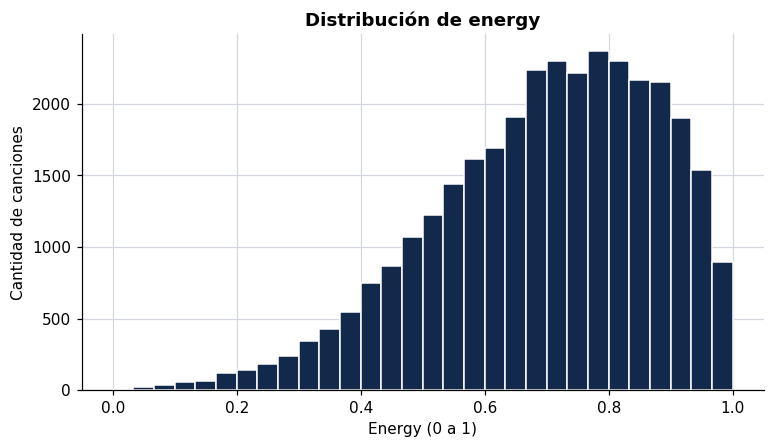

Skew: -0.6363298409581123


In [3]:
# a) Media, mediana, desviación estándar y rango de energy
media = df["energy"].mean()
mediana = df["energy"].median()
desviacion = df["energy"].std()
rango = df["energy"].max() - df["energy"].min()

print("Media:", media)
print("Mediana:", mediana)
print("Desviación estándar:", desviacion)
print("Rango:", rango)


# b) Histograma

plt.hist(df["energy"], bins=30, color=AZUL, edgecolor="white")
plt.xlabel("Energy (0 a 1)")
plt.ylabel("Cantidad de canciones")
plt.title("Distribución de energy")
plt.show()


# c) Asimetría
asimetria = df["energy"].skew()
print("Skew:", asimetria)

### 📝 Tu respuesta — Ejercicio 2

**1.** Escribe los cuatro números de (a) en una frase.

Para energy, la media me dio 0.6986, que redondeada es 0.70, la mediana fue 0.721, que redondeada es 0.72, la desviación estándar fue 0.1809, que redondeada es 0.18, y el rango fue 0.9998, que redondeado es aproximadamente 1.00. Lo que más me llamó la atención es que la media y la mediana quedaron bastante cerca.

**2.** ¿La media quedó por encima o por debajo de la mediana? ¿Hacia qué lado está la cola?
   ¿Coincide eso con el signo del `skew()` y con lo que ves en el histograma?

La media quedó un poco por debajo de la mediana. En el histograma se nota que la mayoría de las canciones están en niveles de energía medios y altos, pero también hay algunas con valores bastante bajos, y por eso la gráfica se alarga hacia la izquierda. El skew me dio -0.6363, que redondeado es -0.64, y eso coincide con lo que se ve en la gráfica.

---
# Ejercicio 3 · ¿En qué se diferencian los géneros?
**Dificultad: baja** · 20 puntos

Ya sabes cómo se reparte `energy` en toda la tabla. La pregunta ahora es si **esa repartición es
la misma dentro de cada género**.

**a)** Calcula la **media** y la **desviación estándar** de `energy` **por género**, en una sola tabla.
Ordénala de mayor a menor por la media y guárdala en una variable llamada `energia_genero`
(la vas a volver a usar en el Ejercicio 5).

**b)** Haz un **gráfico de barras horizontales** con la media de `energy` por género.
Ordenado por valor, con título y etiqueta de eje.

**c)** Haz un **boxplot** de `energy` por género.

> 💡 **Pistas.**
> `df.groupby("playlist_genre")["energy"].agg(["mean", "std"])` da las dos columnas de una vez;
> después `.sort_values("mean", ascending=False)`.
> Barras horizontales: `plt.barh(serie.index, serie.values, color=AZUL)` — ordena la serie de
> **menor a mayor** para que la barra más larga quede arriba.
> Boxplot: `df.boxplot(column="energy", by="playlist_genre")`, o armando la lista de grupos
> como hicimos en el laboratorio de la Clase 3.
>
> ⚠️ "Más enérgico" y "más disperso" son preguntas distintas: la primera la contesta la media,
> la segunda la desviación estándar. No asumas que van juntas.

                    mean       std
playlist_genre                    
edm             0.802476  0.139415
rock            0.732813  0.194501
latin           0.708312  0.152308
pop             0.701028  0.171084
rap             0.650708  0.170340
r&b             0.590934  0.179407


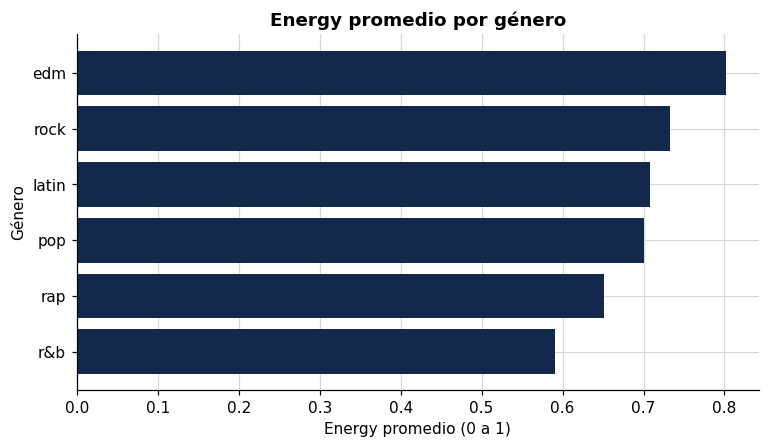

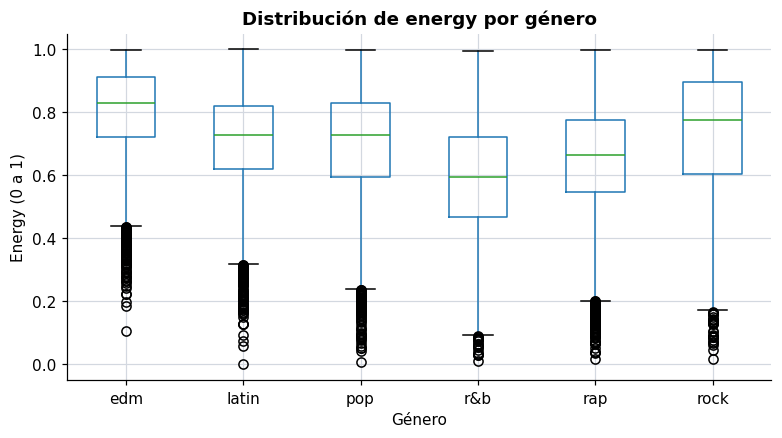

In [4]:
# a) Media y desviación de energy por género
energia_genero = df.groupby("playlist_genre")["energy"].agg(["mean", "std"])
energia_genero = energia_genero.sort_values("mean", ascending=False)

print(energia_genero)

# b) Gráfico de barras horizontales
energia_ordenada = energia_genero["mean"].sort_values()

plt.barh(energia_ordenada.index, energia_ordenada.values, color=AZUL)
plt.xlabel("Energy promedio (0 a 1)")
plt.ylabel("Género")
plt.title("Energy promedio por género")
plt.show()


# c) Boxplot
df.boxplot(column="energy", by="playlist_genre")
plt.xlabel("Género")
plt.ylabel("Energy (0 a 1)")
plt.title("Distribución de energy por género")
plt.suptitle("")
plt.show()




### 📝 Tu respuesta — Ejercicio 3

**1.** ¿Cuál es el género **más enérgico** en promedio y cuál el **menos**? Da los dos números.

>El género que salió con mayor nivel de energy en promedio fue EDM con 0.8025, mientras que el menor fue R&B con 0.5909. Al ver la diferencia en la gráfica, se nota bastante que las canciones de EDM tienden a tener más energía que las de R&B.

**2.** ¿Cuál es el género **más disperso** (mayor desviación estándar)? ¿Es el mismo que el más
   enérgico? ¿Qué significa, en palabras, que un género tenga mucha dispersión en `energy`?

>El género con mayor dispersión fue rock, con una desviación estándar de 0.1945, y no es el mismo que tuvo el promedio de energy más alto, que fue EDM. Lo que esto me dice es que dentro del rock hay canciones con niveles de energía bastante diferentes entre sí. Algunas pueden tener una energía alta y otras una energía mucho más baja, por lo que el género no se comporta de una sola manera en ese aspecto.

**3.** Tapa el código y mira solo tu gráfico de barras. ¿Lo pondrías en un informe sin escribir
   un párrafo explicándolo? Si no, arréglalo antes de seguir.

>Sí, yo sí lo pondría en un informe porque al verlo se entiende rápido cuál género tiene más energy y cuál tiene menos. Como está ordenado, la comparación se hace fácil sin tener que leer demasiado. También tiene un título claro y los nombres de los ejes, así que se puede entender la idea principal casi de inmediato.

---
# Ejercicio 4 · Buscar relaciones entre variables
**Dificultad: media** · 25 puntos

Hasta aquí miraste variables **una por una**. Ahora las miramos **de a dos**: ¿cuáles se mueven
juntas?

**a)** Calcula la **matriz de correlación** de las 10 variables de la lista `audio`.

**b)** Conviértela en una lista ordenada de pares y encuentra el par **más positivo** y el
**más negativo**. Ojo con dos cosas antes de ordenar:
- la **diagonal** (toda variable correlaciona 1 consigo misma) hay que quitarla;
- la matriz es **simétrica**, así que cada par aparece dos veces: quédate con una sola copia.
Si lo haces bien, tu lista debe tener **45 pares**, no 90.

**c)** Grafica el par **más positivo** con un diagrama de dispersión.
Con 32,833 puntos la nube se vuelve una mancha: usa una muestra y transparencia.

**d)** Calcula ahora la correlación de cada variable de `audio` con `track_popularity`.
¿Cuál es la que más se relaciona con la popularidad?

> 💡 **Pistas.**
> `corr = df[audio].corr()`
> ```python
> pares = corr.unstack()
> pares = pares[pares < 0.999]                                       # fuera la diagonal
> pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)]  # fuera repetidos
> pares = pares.sort_values()
> ```
> El primero y el último de esa lista son los que buscas.
> Para el gráfico: `m = df.sample(4000, random_state=1)` y luego
> `plt.scatter(m["x"], m["y"], s=6, alpha=0.25, color=AZUL, lw=0)`.
> Para (d): `df[audio + ["track_popularity"]].corr()["track_popularity"].sort_values()`.

                  danceability    energy  loudness  speechiness  acousticness  \
danceability          1.000000 -0.086073  0.025335     0.181721     -0.024519   
energy               -0.086073  1.000000  0.676625    -0.032150     -0.539745   
loudness              0.025335  0.676625  1.000000     0.010339     -0.361638   
speechiness           0.181721 -0.032150  0.010339     1.000000      0.026092   
acousticness         -0.024519 -0.539745 -0.361638     0.026092      1.000000   
instrumentalness     -0.008655  0.033247 -0.147824    -0.103424     -0.006850   
liveness             -0.123859  0.161223  0.077613     0.055426     -0.077243   
valence               0.330523  0.151103  0.053384     0.064659     -0.016845   
tempo                -0.184084  0.149951  0.093767     0.044603     -0.112724   
duration_min         -0.096879  0.012611 -0.115058    -0.089431     -0.081581   

                  instrumentalness  liveness   valence     tempo  duration_min  
danceability             -0

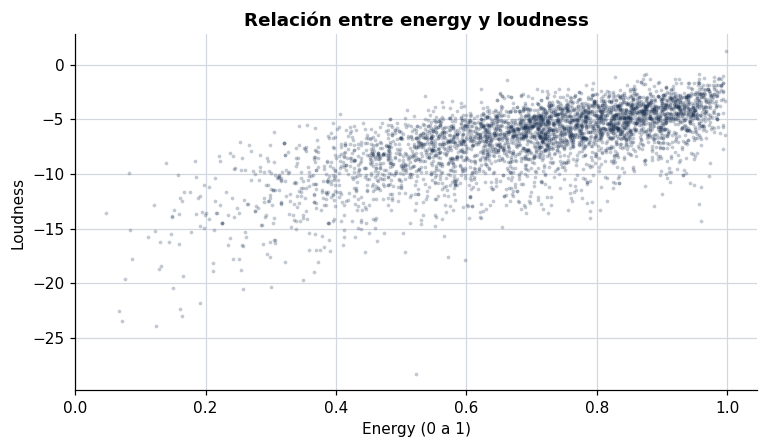

instrumentalness   -0.149872
duration_min       -0.143682
energy             -0.109112
liveness           -0.054584
tempo              -0.005378
speechiness         0.006819
valence             0.033231
loudness            0.057687
danceability        0.064748
acousticness        0.085159
track_popularity    1.000000
Name: track_popularity, dtype: float64


In [5]:
# a) Matriz de correlación
corr = df[audio].corr()
print(corr)


# b) Lista de pares ordenada: el más positivo y el más negativo
pares = corr.unstack()
pares = pares[pares < 0.999]
pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)]
pares = pares.sort_values()

print("Cantidad de pares:", len(pares))
print("Más negativo:")
print(pares.head(1))

print("Más positivo:")
print(pares.tail(1))


# c) Diagrama de dispersión del par más positivo
m = df.sample(4000, random_state=1)

plt.scatter(m["energy"], m["loudness"], s=6, alpha=0.25, color=AZUL, lw=0)
plt.xlabel("Energy (0 a 1)")
plt.ylabel("Loudness")
plt.title("Relación entre energy y loudness")
plt.show()


# d) Correlación de cada variable de audio con track_popularity
popularidad = df[audio + ["track_popularity"]].corr()["track_popularity"].sort_values()
print(popularidad)


### 📝 Tu respuesta — Ejercicio 4

**1.** ¿Cuál es el par con la correlación **positiva** más fuerte y cuál con la **negativa** más
   fuerte? Da los dos valores de r.

> El par con la correlación positiva más fuerte es energy y loudness, con r = 0.676625. En cambio, la correlación negativa más fuerte es entre acousticness y energy, con r = -0.539745.

**2.** Mira tu diagrama de dispersión. La correlación es alta, pero la nube **no** es una línea.
   ¿Qué te dice eso sobre lo que r puede y no puede predecir para **una** canción concreta?

> Al mirar la gráfica, sí se nota que cuando aumenta energy, generalmente también aumenta loudness, pero los puntos están bastante separados y no forman una línea. Para mí esto significa que r me ayuda a ver cómo se comportan las canciones en general, pero no me permite tomar una canción específica y saber exactamente su loudness solamente conociendo su energy.

**3.** Escribe **una frase de veredicto** sobre el par más positivo: ¿se puede afirmar que una
   variable **causa** a la otra? Antes de responder descarta las tres alternativas que vimos en
   clase: una **variable oculta** que mueva a las dos, la **causa invertida**, o la **coincidencia**.

> No se puede afirmar que energy cause directamente el loudness, porque todavía podría haber una variable oculta que afecte a las dos, la relación podría estar ocurriendo al revés de como la estamos interpretando o parte de lo que vemos podría ser coincidencia; por eso, con estos datos solo puedo decir que están relacionadas.

**4.** De las 10 variables de audio, ¿cuál correlaciona más con `track_popularity`? ¿Es una
   relación fuerte o débil? ¿Te sirve ese número solo para predecir si una canción será popular?

>De las 10 variables, la que más se relacionó con track_popularity fue instrumentalness, con r = -0.149872. Es una relación bastante débil porque el valor está cerca de cero. Por eso, no me serviría ese número por sí solo para decir si una canción va a ser popular o no; al menos con estos resultados, parece que la popularidad depende de muchas más cosas que solamente de una característica de audio.

---
# Ejercicio 5 · La relación escondida
**Dificultad: media** · 25 puntos

En el Ejercicio 4 calculaste correlaciones sobre **toda la tabla**. Pero en el Ejercicio 3
comprobaste que los géneros son muy distintos entre sí. La pregunta final del problem set es qué
pasa cuando juntas las dos cosas.

Trabaja con el par **`energy` y `danceability`**.

**a)** Calcula la correlación entre `energy` y `danceability` **en el conjunto completo**.

**b)** Calcula **esa misma correlación dentro de cada género**. Arma una tabla con los seis
valores, ordenada, y guárdala en `corr_genero`.

**c)** Junta en una sola tabla, para cada género: la **media de energy** (la tienes en
`energia_genero`, del Ejercicio 3), la **media de `danceability`**, la **media de
`track_popularity`** y la **correlación** de (b).

**d)** Estandariza `energy` creando la columna `energy_z`, y encuentra la canción con el
**z más alto**. Muestra su nombre, artista, género, `energy` y `energy_z`.
Comprueba además que `energy_z` tiene media 0 y desviación 1, y que su `skew()` es el mismo
que el de `energy` original.

> 💡 **Pistas.**
> Correlación por grupo:
> `df.groupby("playlist_genre").apply(lambda g: g["energy"].corr(g["danceability"])).sort_values()`
> El `lambda g:` recibe el sub-DataFrame de cada género.
> Para juntar tablas que comparten el mismo índice (el género): `pd.concat([tabla1, tabla2], axis=1)`.
> Estandarización: `z = (x - x.mean()) / x.std()`.
> `.idxmax()` devuelve el **índice** de la fila con el valor máximo; con `df.loc[idx, [...]]`
> sacas las columnas que quieras de esa fila.
>
> ⚠️ Antes de escribir la conclusión, mira los **signos** de la tabla de (b): ¿todos los géneros
> apuntan hacia el mismo lado?

In [6]:
# a) Correlación global entre energy y danceability
corr_global = df["energy"].corr(df["danceability"])
print("Correlación global:", corr_global)


# b) La misma correlación dentro de cada género
corr_genero = df.groupby("playlist_genre").apply(
    lambda g: g["energy"].corr(g["danceability"])
).sort_values()

print(corr_genero)

# c) Tabla resumen por género

dance_genero = df.groupby("playlist_genre")["danceability"].mean()
popularidad_genero = df.groupby("playlist_genre")["track_popularity"].mean()

resumen_genero = pd.concat(
    [
        energia_genero["mean"],
        dance_genero,
        popularidad_genero,
        corr_genero
    ],
    axis=1
)

resumen_genero.columns = [
    "energy_media",
    "danceability_media",
    "popularidad_media",
    "correlacion"
]

print(resumen_genero)


# d) Estandarización de energy y canción más extrema

df["energy_z"] = (
    df["energy"] - df["energy"].mean()
) / df["energy"].std()

idx = df["energy_z"].idxmax()

print(
    df.loc[
        idx,
        [
            "track_name",
            "track_artist",
            "playlist_genre",
            "energy",
            "energy_z"
        ]
    ]
)

print("Media de energy_z:", df["energy_z"].mean())
print("Desviación de energy_z:", df["energy_z"].std())

print("Skew de energy:", df["energy"].skew())
print("Skew de energy_z:", df["energy_z"].skew())


Correlación global: -0.08607315593777097
playlist_genre
rock    -0.152882
edm     -0.150262
rap     -0.148173
pop     -0.030729
latin    0.115939
r&b      0.159201
dtype: float64
                energy_media  danceability_media  popularidad_media  \
playlist_genre                                                        
edm                 0.802476            0.655041          34.833526   
rock                0.732813            0.520548          41.728338   
latin               0.708312            0.713287          47.026576   
pop                 0.701028            0.639302          47.744870   
rap                 0.650708            0.718353          43.215454   
r&b                 0.590934            0.670179          41.223532   

                correlacion  
playlist_genre               
edm               -0.150262  
rock              -0.152882  
latin              0.115939  
pop               -0.030729  
rap               -0.148173  
r&b                0.159201  
track_name  

### 📝 Tu respuesta — Ejercicio 5

**1.** ¿Cuánto vale r en el conjunto completo? ¿Cuál es el género con el r **más negativo** y
   cuál con el **más positivo**? Da los tres números.

> En el conjunto completo, la correlación entre energy y danceability fue de r = -0.0861. El género con la correlación más negativa fue rock, con r = -0.1529, y el más positivo fue R&B, con r = 0.1592.

**2.** Si el r global es cercano a cero, ¿se puede concluir que `energy` y `danceability`
   no tienen ninguna relación? Explica qué está pasando por debajo del promedio global.
   ¿Cuál es la "tercera variable" de la que hablamos en la lámina de correlación y causalidad?

> No, que la correlación global esté cerca de cero no significa que no exista ninguna relación. Cuando separé las canciones por género vi que no todos se comportan igual: rock, EDM y rap tienen una relación negativa, mientras que latin y R&B tienen una relación positiva. Al juntar todos los géneros, esas diferencias se mezclan y por eso el resultado global termina cerca de cero. En este caso, la tercera variable que está influyendo en lo que vemos es el género musical.

**3.** Mira la tabla de (c) junto con lo que sacaste en el Ejercicio 4(d). ¿El género con la
   energía media más alta es también el más popular? ¿Qué le dirías a la plataforma de streaming
   si te pidiera "subirle la energía a las canciones para que sean más populares"?

> No. EDM fue el género con mayor energy promedio, con 0.8025, pero su popularidad promedio fue de 34.83, mientras que pop tuvo la popularidad promedio más alta, con 47.74, aun teniendo un energy promedio menor de 0.7010. Por eso, si la plataforma me dijera que aumentemos la energía de las canciones para hacerlas más populares, yo no recomendaría hacerlo basándonos solamente en estos datos, porque aquí no se ve que tener más energy signifique tener más popularidad.

**4.** La canción con el `energy_z` más alto: ¿qué tan lejos de la media está, en desviaciones
   estándar? ¿Por qué el `skew()` de `energy_z` es idéntico al de `energy`, si le restamos la
   media y la dividimos entre la desviación?

> La canción con el energy_z más alto quedó a aproximadamente 1.67 desviaciones estándar por encima de la media. El skew quedó prácticamente igual antes y después, cerca de -0.6363, porque al estandarizar solamente cambiamos la escala de los valores: los movemos para que la media quede en 0 y los ajustamos por la desviación estándar, pero la forma que tienen los datos no cambia. Por eso la inclinación hacia un lado sigue siendo la misma.

---
# Cierre · El entregable escrito

Escribe **un párrafo de 4 a 6 frases** dirigido a alguien que **no tomó este curso** —el gerente
de producto de la plataforma de streaming— con el hallazgo principal del problem set.

Requisitos:

1. Empieza por el **hallazgo**, no por el método.
2. Usa **al menos tres números** de los que calculaste, indicando de qué ejercicio salen.
3. **Sin jerga**: nada de "r", "desviación estándar" ni "skew" sin traducir a español común.
4. Cierra con **una advertencia**: algo que estos datos **NO** permiten concluir.

> 💡 "r = 0.06" no es una frase. "En el conjunto completo parece que no hay relación, pero es
> porque dos géneros se comportan al revés y se cancelan entre sí" sí lo es.

### 📝 Tu párrafo

> El principal hallazgo es que una canción no parece volverse más popular solo por tener más energía, y además el género cambia bastante la forma en que se comportan esas características. En el Ejercicio 5 vimos que, al analizar todas las canciones juntas, la relación entre energy y danceability fue de apenas -0.0861, pero al separarlas por género cambió bastante: en rock fue de -0.1529 y en R&B llegó a 0.1592, lo que muestra que no todos los géneros siguen el mismo patrón. También vimos que EDM fue el género con mayor nivel promedio de energía, con 0.8025, pero su popularidad promedio fue de 34.83, mientras que pop alcanzó una popularidad promedio de 47.74 con una energía menor, de 0.7010. Otro dato que llamó la atención en el Ejercicio 4 es que instrumentalness fue la característica de audio que más se relacionó con la popularidad, pero el valor fue de solo -0.1499, así que tampoco parece explicar por sí sola qué canciones terminan siendo más populares. Con estos resultados, no recomendaría subir la energía de las canciones esperando que eso aumente su popularidad, porque los datos muestran asociaciones y diferencias entre géneros, pero no permiten asegurar que cambiar una característica vaya a causar más popularidad.


---

### 🤖 Uso de IA

¿En qué ejercicios usaste IA? Para cada uno, explica **qué hace ese código** o **qué alternativa
pensaste antes de preguntar**.

> Usé IA como apoyo en algunas partes del problem set, sobre todo cuando había código que no tenía tan claro cómo hacer. En el Ejercicio 4 me ayudó a entender cómo pasar la matriz de correlación a una lista de pares, quitar los repetidos y poder identificar cuál era la relación positiva y negativa más fuerte. Yo sabía que tenía que comparar las variables, pero no tenía claro cómo organizar esos pares sin contar dos veces la misma relación. En el Ejercicio 5 la usé principalmente porque no conocía bien cómo funcionaba lambda dentro de groupby().apply(), y entendí que ese código toma cada género por separado y calcula dentro de cada uno la relación entre energy y danceability. También me ayudó a entender que por eso el resultado general podía verse diferente al resultado por género.


---

### ✅ Antes de entregar, verifica:

- [ ] Kernel → Restart & Run All: el cuaderno corre de principio a fin **sin errores**.
- [ ] Todos los gráficos tienen **título** y **etiquetas de eje con unidad**.
- [ ] Todas las celdas de *Tu respuesta* están contestadas.
- [ ] El cuaderno está en **GitHub** con el nombre `S100_PS1_TuApellido.ipynb`.
- [ ] Envié el **enlace** (y solo el enlace) a gabriel.soto@utp.ac.pa.
- [ ] Agregué el enlace en `S100 Lista Estudiantes Provisional`, carpeta `01_administracion`
      del SharePoint, junto a mi nombre.